In [1]:
import sys
sys.path.append('/workspaces/knot_mosaics/training')

In [2]:
from model import *

Using device: cpu


Loading data from data.py...
Detected matrix dimensions: 10x10 (input_size=100)
Training samples: 6400
Validation samples: 1600
Test samples: 2000

Training model...
Epoch [10/3000]
  Train Loss: 0.0053, Train Acc: 0.9983
  Val Loss: 0.0039, Val Acc: 0.9981
Epoch [20/3000]
  Train Loss: 0.0024, Train Acc: 0.9992
  Val Loss: 0.0050, Val Acc: 0.9975
Epoch [30/3000]
  Train Loss: 0.0019, Train Acc: 0.9997
  Val Loss: 0.0012, Val Acc: 1.0000
Epoch [40/3000]
  Train Loss: 0.0006, Train Acc: 0.9998
  Val Loss: 0.0043, Val Acc: 0.9975
Epoch [50/3000]
  Train Loss: 0.0011, Train Acc: 0.9998
  Val Loss: 0.0023, Val Acc: 0.9988
Epoch [60/3000]
  Train Loss: 0.0015, Train Acc: 0.9995
  Val Loss: 0.0023, Val Acc: 0.9988
Epoch [70/3000]
  Train Loss: 0.0001, Train Acc: 1.0000
  Val Loss: 0.0025, Val Acc: 0.9988
Epoch [80/3000]
  Train Loss: 0.0004, Train Acc: 0.9998
  Val Loss: 0.0025, Val Acc: 0.9988
Epoch [90/3000]
  Train Loss: 0.0002, Train Acc: 1.0000
  Val Loss: 0.0025, Val Acc: 0.9988
Epoch 

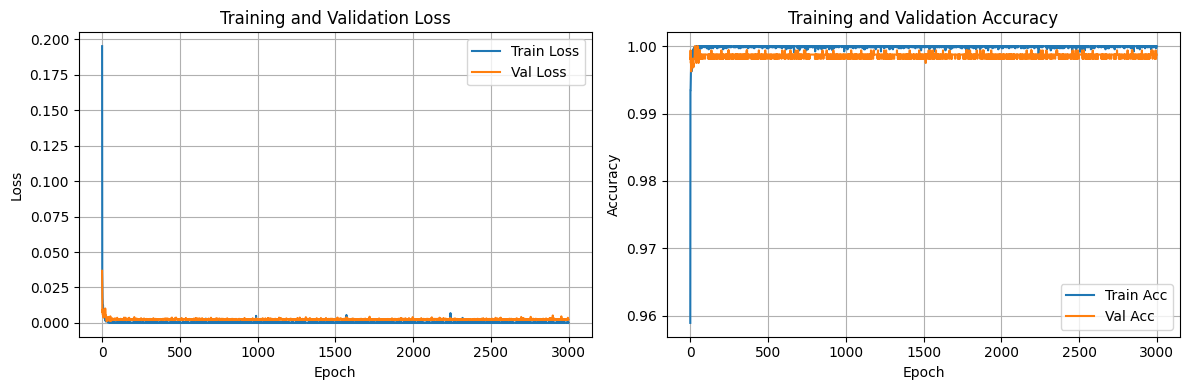


Model saved as '/workspaces/knot_mosaics/training/matrix_classifier_model.pth'


In [3]:
trained_model = main(epochs=3000)

In [4]:
import time
start_time = time.time()

# Your new matrix to classify (dimensions should match training data)
new_matrix = [(0, 2, 5, 1, 2, 5, 1, 2, 5, 5, 5, 5, 5, 5, 1),
              (2, 7, 5, 9, 7, 5, 9, 10, 1, 0, 0, 2, 5, 1, 6),
              (3, 10, 5, 4, 3, 1, 6, 6, 6, 2, 5, 10, 1, 3, 4),
              (2, 4, 2, 1, 2, 9, 7, 10, 10, 8, 5, 7, 7, 1, 0),
              (3, 1, 6, 3, 9, 10, 8, 7, 7, 7, 5, 9, 9, 7, 1),
              (0, 6, 6, 2, 8, 4, 3, 10, 7, 10, 1, 3, 10, 7, 4),
              (0, 6, 6, 6, 6, 2, 5, 4, 3, 7, 4, 2, 8, 8, 1),
              (2, 10, 9, 9, 9, 10, 1, 2, 5, 4, 0, 6, 3, 10, 4),
              (6, 3, 8, 10, 10, 10, 8, 10, 1, 2, 1, 3, 5, 10, 1),
              (6, 2, 8, 7, 7, 8, 10, 8, 4, 3, 8, 5, 5, 7, 4),
              (3, 8, 10, 10, 4, 6, 3, 8, 5, 5, 4, 2, 1, 3, 1),
              (2, 8, 10, 4, 0, 3, 5, 8, 5, 5, 5, 7, 4, 0, 6),
              (6, 3, 10, 1, 2, 1, 2, 9, 5, 1, 0, 6, 0, 0, 6),
              (3, 1, 3, 4, 6, 3, 10, 8, 1, 6, 0, 6, 0, 0, 6),
              (0, 3, 5, 5, 4, 0, 3, 4, 3, 4, 0, 3, 5, 5, 4)]

prediction, confidence = predict_single_matrix(trained_model, new_matrix)

end_time = time.time()
print(f"Prediction: {prediction} (confidence: {confidence:.2%})")
print(f"Execution time: {end_time - start_time:.6f} seconds")

Prediction: 1 (confidence: 99.71%)
Execution time: 0.015087 seconds


In [4]:
from unseen_data import unseen_data_pairs


def predict_batch(model, matrices_list):
    model.eval()

    # Convert all matrices to a tensor batch
    batch = torch.FloatTensor(matrices_list).to(device)

    with torch.no_grad():
        outputs = model(batch).squeeze()
        predictions = (outputs > 0.5).int().tolist()
        confidences = [o.item() if p == 1 else 1-o.item()
                       for o, p in zip(outputs, predictions)]

    return predictions, confidences


# Extract just the matrices from unseen_data_pairs (which contains tuples of (matrix, label))
unseen_matrices = [matrix for matrix, label in unseen_data_pairs]
actual_labels = [label for matrix, label in unseen_data_pairs]

# Run predictions (assuming model is trained/loaded)
predictions, confidences = predict_batch(trained_model, unseen_matrices)

# Display results and track outliers
outliers = []
for i, (pred, conf, actual) in enumerate(zip(predictions, confidences, actual_labels)):
    print(f"Matrix {i+1}: Class {pred} (confidence: {conf:.2%})")
    if pred != actual:
        outliers.append({
            'index': i + 1,
            'predicted': pred,
            'actual': actual,
            'confidence': conf,
            'matrix': unseen_matrices[i]
        })

# Print outliers at the end
if outliers:
    print("\n" + "="*60)
    print("OUTLIERS - Predictions that don't match actual labels:")
    print("="*60)
    for outlier in outliers:
        print(f"Matrix {outlier['index']}: Predicted {outlier['predicted']}, "
              f"Actual {outlier['actual']} (confidence: {outlier['confidence']:.2%})")
        print(f"  Matrix data: {outlier['matrix']}")
else:
    print("\n" + "="*60)
    print("No outliers found - all predictions match actual labels!")
    print("="*60)

Matrix 1: Class 0 (confidence: 100.00%)
Matrix 2: Class 0 (confidence: 100.00%)
Matrix 3: Class 1 (confidence: 100.00%)
Matrix 4: Class 1 (confidence: 100.00%)
Matrix 5: Class 1 (confidence: 100.00%)
Matrix 6: Class 0 (confidence: 100.00%)
Matrix 7: Class 1 (confidence: 100.00%)
Matrix 8: Class 0 (confidence: 100.00%)
Matrix 9: Class 1 (confidence: 100.00%)
Matrix 10: Class 0 (confidence: 100.00%)
Matrix 11: Class 1 (confidence: 100.00%)
Matrix 12: Class 0 (confidence: 100.00%)
Matrix 13: Class 1 (confidence: 100.00%)
Matrix 14: Class 1 (confidence: 100.00%)
Matrix 15: Class 1 (confidence: 100.00%)
Matrix 16: Class 1 (confidence: 100.00%)
Matrix 17: Class 1 (confidence: 100.00%)
Matrix 18: Class 1 (confidence: 100.00%)
Matrix 19: Class 1 (confidence: 99.99%)
Matrix 20: Class 0 (confidence: 100.00%)
Matrix 21: Class 1 (confidence: 100.00%)
Matrix 22: Class 1 (confidence: 100.00%)
Matrix 23: Class 0 (confidence: 100.00%)
Matrix 24: Class 1 (confidence: 100.00%)
Matrix 25: Class 1 (confid